In [1]:
import sys
sys.path.append("/home/abernier/scratch/rm-search-Bernier-2025/scripts")

from plot_utils import *  # contains all plotting functions
import numpy as np
import astropy.units as u
import glob
import os
import argparse

from pulse_utils import downsample_time_mean
import numpy as np
import astropy.units as u
import colorsys
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

In [129]:
SOURCE="2022_CHIME_B2111+46"
OBS_NIGHT="20220826T064420Z"

SETTINGS="timeavg391_nfiles300_allfiles_RFI1.7mean1.3std"
SUBDIR="start_file_ind_dm141"
RESULTS_DIR=f"/scratch/abernier/results_data/{SOURCE}/{OBS_NIGHT}/{SETTINGS}/{SUBDIR}"  # input
SAVE_FIG_DIR=f"/scratch/abernier/results_figures/{SOURCE}/{OBS_NIGHT}/{SETTINGS}/{SUBDIR}"   # input+output

PARAM_LABEL="Start File Index"  # Label for the x-axis corresponding to the varied parameter (e.g., 'Downsampling Factor', 'DM [pc/cm^3]')
DATA_FILES_UNIQUE=0

In [130]:
METADATA_FILES = sorted(
    glob.glob(os.path.join(RESULTS_DIR, "*_metadata.npz")),
    key=len
)
TIMINGS_FILES = sorted(
    glob.glob(os.path.join(RESULTS_DIR, "*_timings.npz")),
    key=len
)
DATA_FILES = sorted(
    glob.glob(os.path.join(RESULTS_DIR, "*_arrays.npz")),
    key=len
)
NFILES = len(DATA_FILES)

In [131]:
BURST_VIS_RESULTS = (       # file with info on pulses visible in stokes I
    f"{SAVE_FIG_DIR}/burst_visible_info.npz"
)
if not os.path.isfile(BURST_VIS_RESULTS):
    print("Pulse detection not run yet. Run 02_pulse_detection.py first to save visible pulse info.")
    exit(1)

TOL = 100
BURST_DETECT_FILES = sorted(    # files with info on detected pulses in FDF
    glob.glob(os.path.join(SAVE_FIG_DIR, f"burst_detected_info_downsamp*_tol{TOL}.npz")),
    key=len
)
if len(BURST_DETECT_FILES) == 0:
    print("Pulse detection not run yet. Run 02_pulse_detection.py first to save detected pulse info.")
    exit(1)

In [132]:
# Define output directories and files
# ==============================================================================
BURST_VIS_DIR = (           # subdirectory for stokes I timeseries plots with visible+detcted pulses marked
    SAVE_FIG_DIR + "/burst_visible_stokesI/"  
)
os.makedirs(BURST_VIS_DIR, exist_ok=True)

os.makedirs(SAVE_FIG_DIR+'/FDFs/', exist_ok=True)  # subdirectory for fdf plots
os.makedirs(SAVE_FIG_DIR+'/stokes/', exist_ok=True)  # subdirectory for stokes plots


# Load visible burst results
# ==============================================================================
visible_dict = np.load(
    BURST_VIS_RESULTS,
    allow_pickle=True
)['visible_dict'].item()

In [94]:
# Load RM search results
# --------------------------------------------------------------------------
param_list = []
data = {}
metadata = {}
timings = {}

for data_file, metadata_file, timings_file in zip(DATA_FILES, METADATA_FILES, TIMINGS_FILES):
    # Get parameter value from filename
    filename = os.path.basename(data_file)  # format: param_name_{param_value}_arrays.npz
    param_value = float(filename.split("_")[-2]) 
    param_list.append(param_value)

    # Load data
    with np.load(data_file, allow_pickle=True) as df:
        data_dict = {k: df[k] for k in df.files}
        data[param_value] = data_dict

    # Load metadata
    with np.load(metadata_file, allow_pickle=True) as mf:
        metadata[param_value] = mf['metadata'][0]

    # # Load timings
    # with np.load(timings_file, allow_pickle=True) as tf:
    #     timings[param_value] = tf['timings'][0]

# sort parameter values in ascending order (just in case)
# DATA_FILES is only sorted by length so eg. 141.26 gets put above 200
param_list = sorted(param_list)

In [95]:
# Get true RMs (using 1st file)
# --------------------------------------------------------------------------
rm_true = list(metadata[param_list[0]]['true_rms_rad_m2'].value)  # true RM of real data
if metadata[param_list[0]]['sim_flag']:
    sim_rm = metadata[param_list[0]]['sim_params']["rm"]  # true RM of injected bursts
    rm_true.append(sim_rm.value)
rm_true = np.array(rm_true)  # shape (Ntrue_rms,)

In [133]:
# ----- Load all detected burst info -----
downsamp_list = []
results_params_all_downsamp = []
results_summary_all_downsamp = []

for file in BURST_DETECT_FILES:
    downsamp = int(os.path.basename(file).split("_")[-2][8:])  # assuming file name 'burst_detected_info_downsamp{FACTOR}_tol{TOL}.npz'
    downsamp_list.append(downsamp)
    
    results = np.load(file, allow_pickle=True)["results"].item()
    results_params_all_downsamp.append(results["params"])
    results_summary_all_downsamp.append(results["summary"])

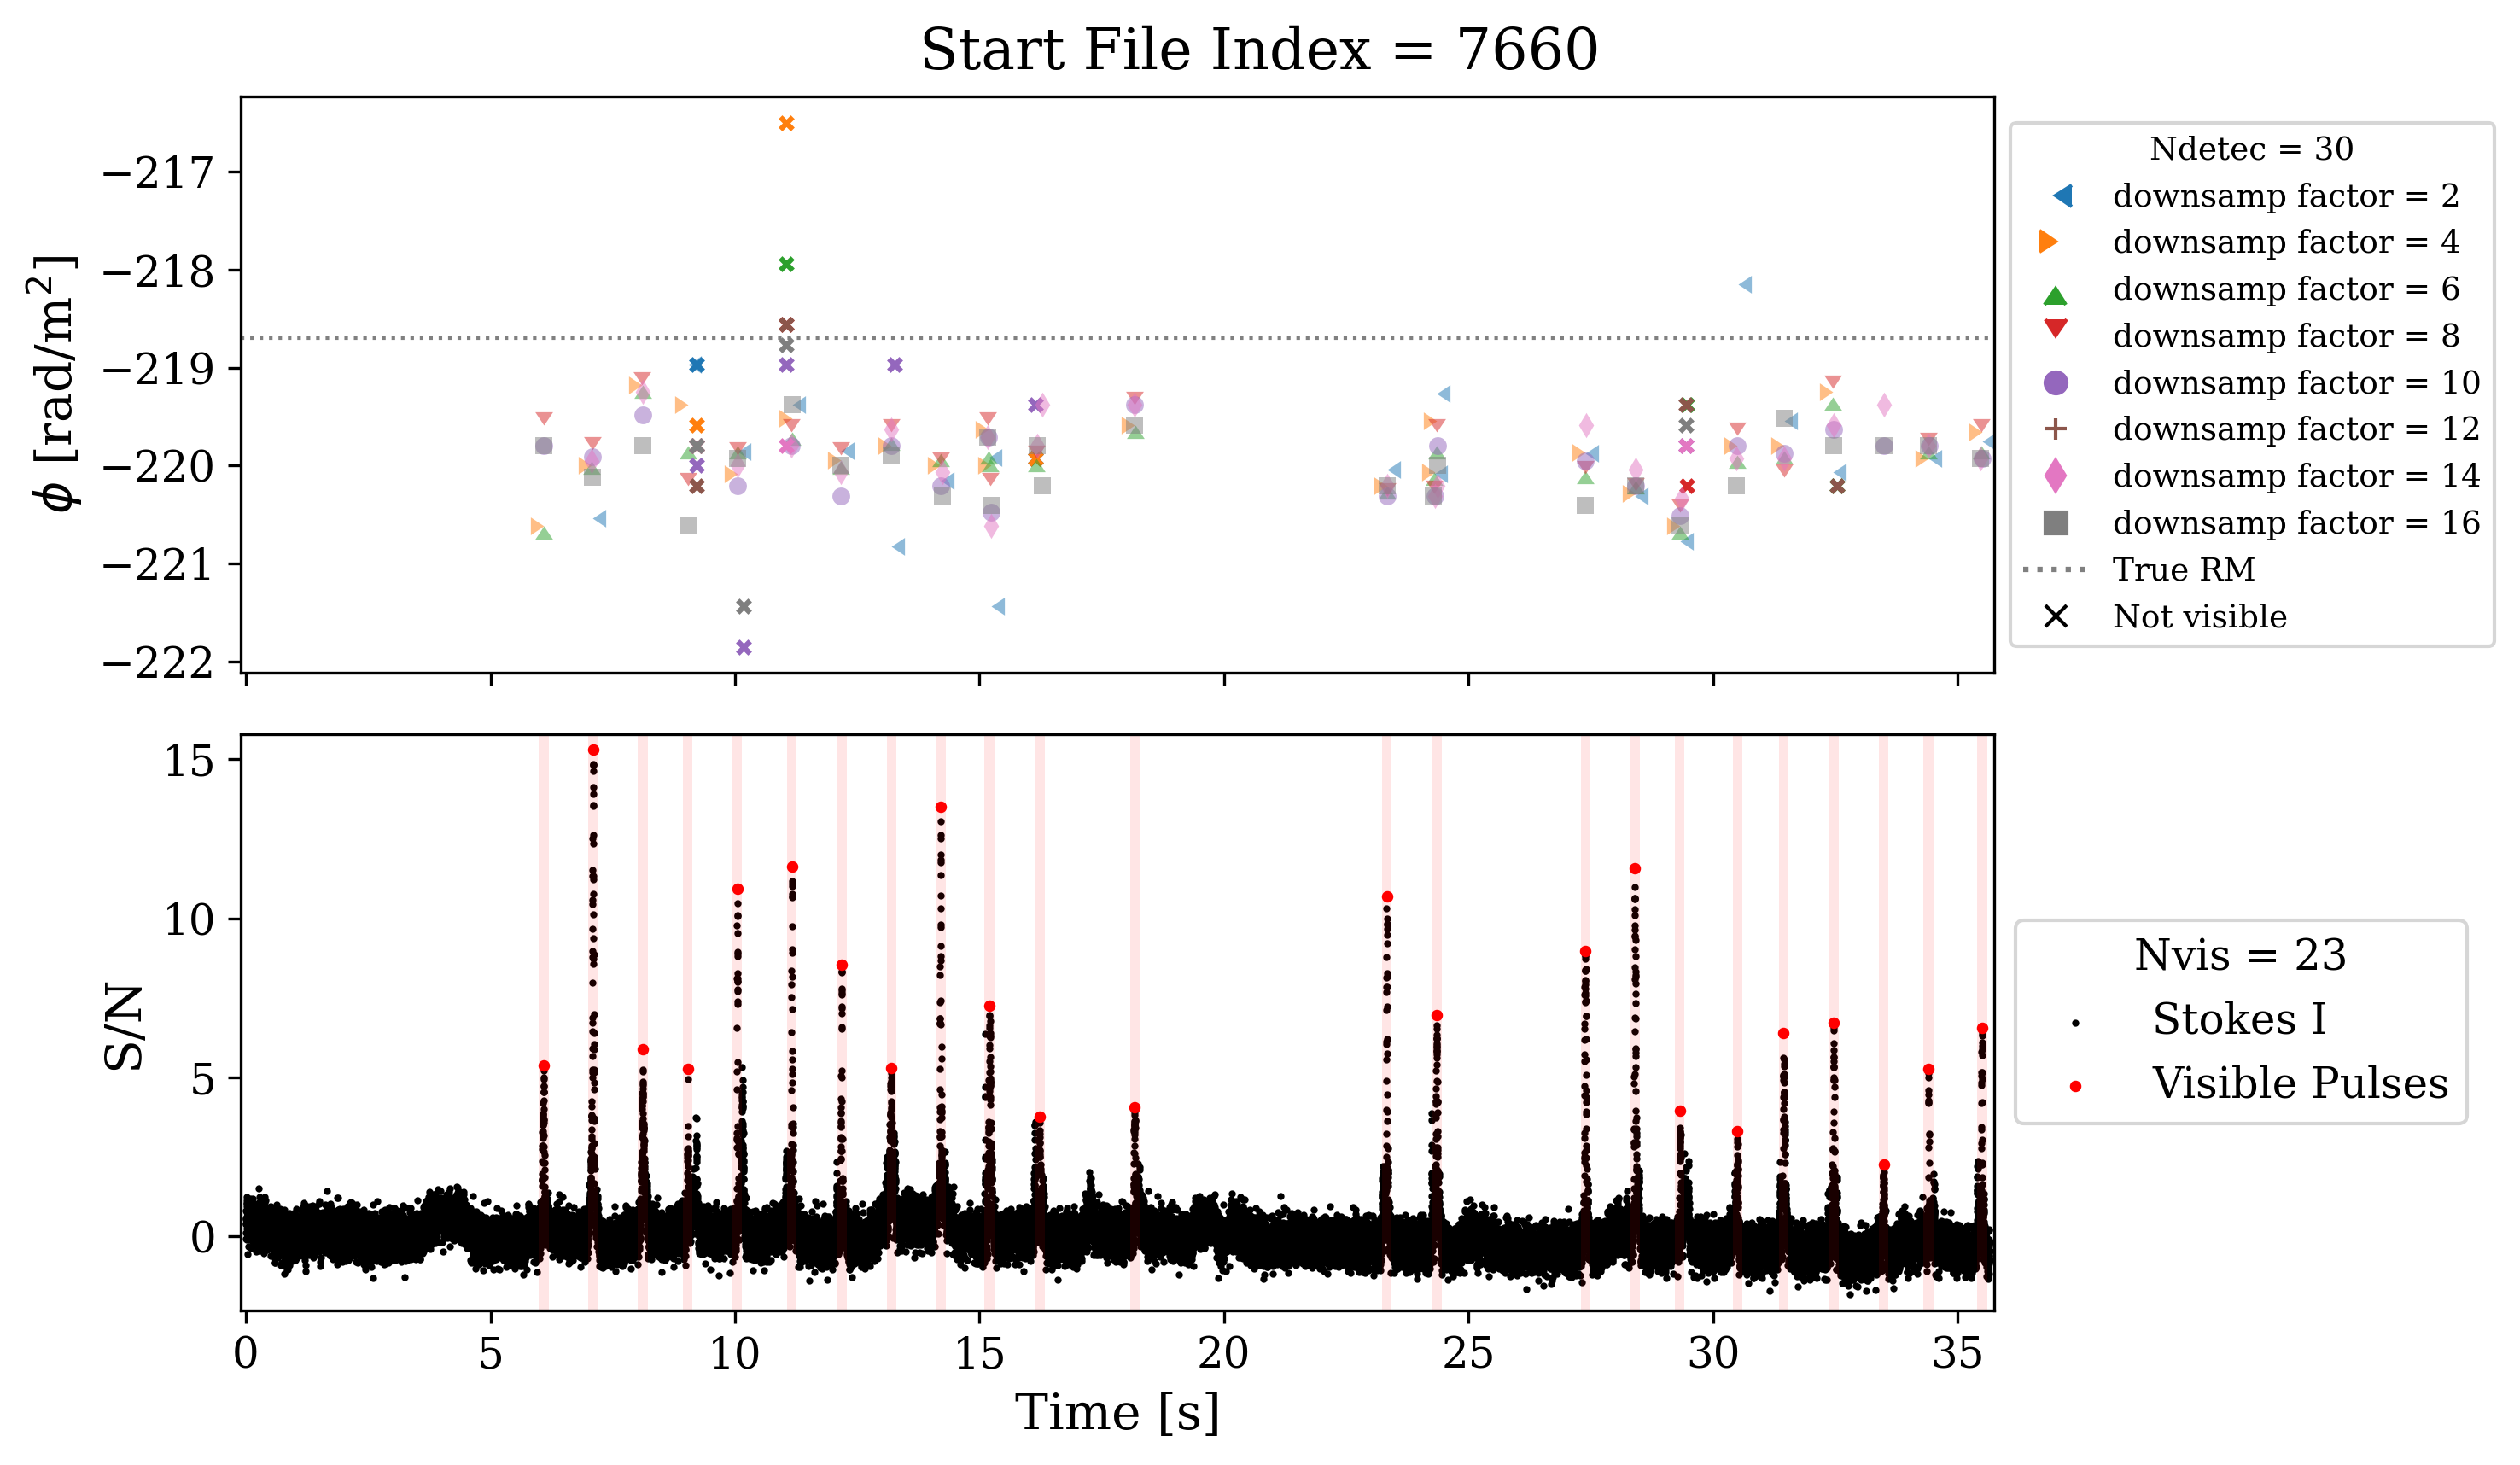

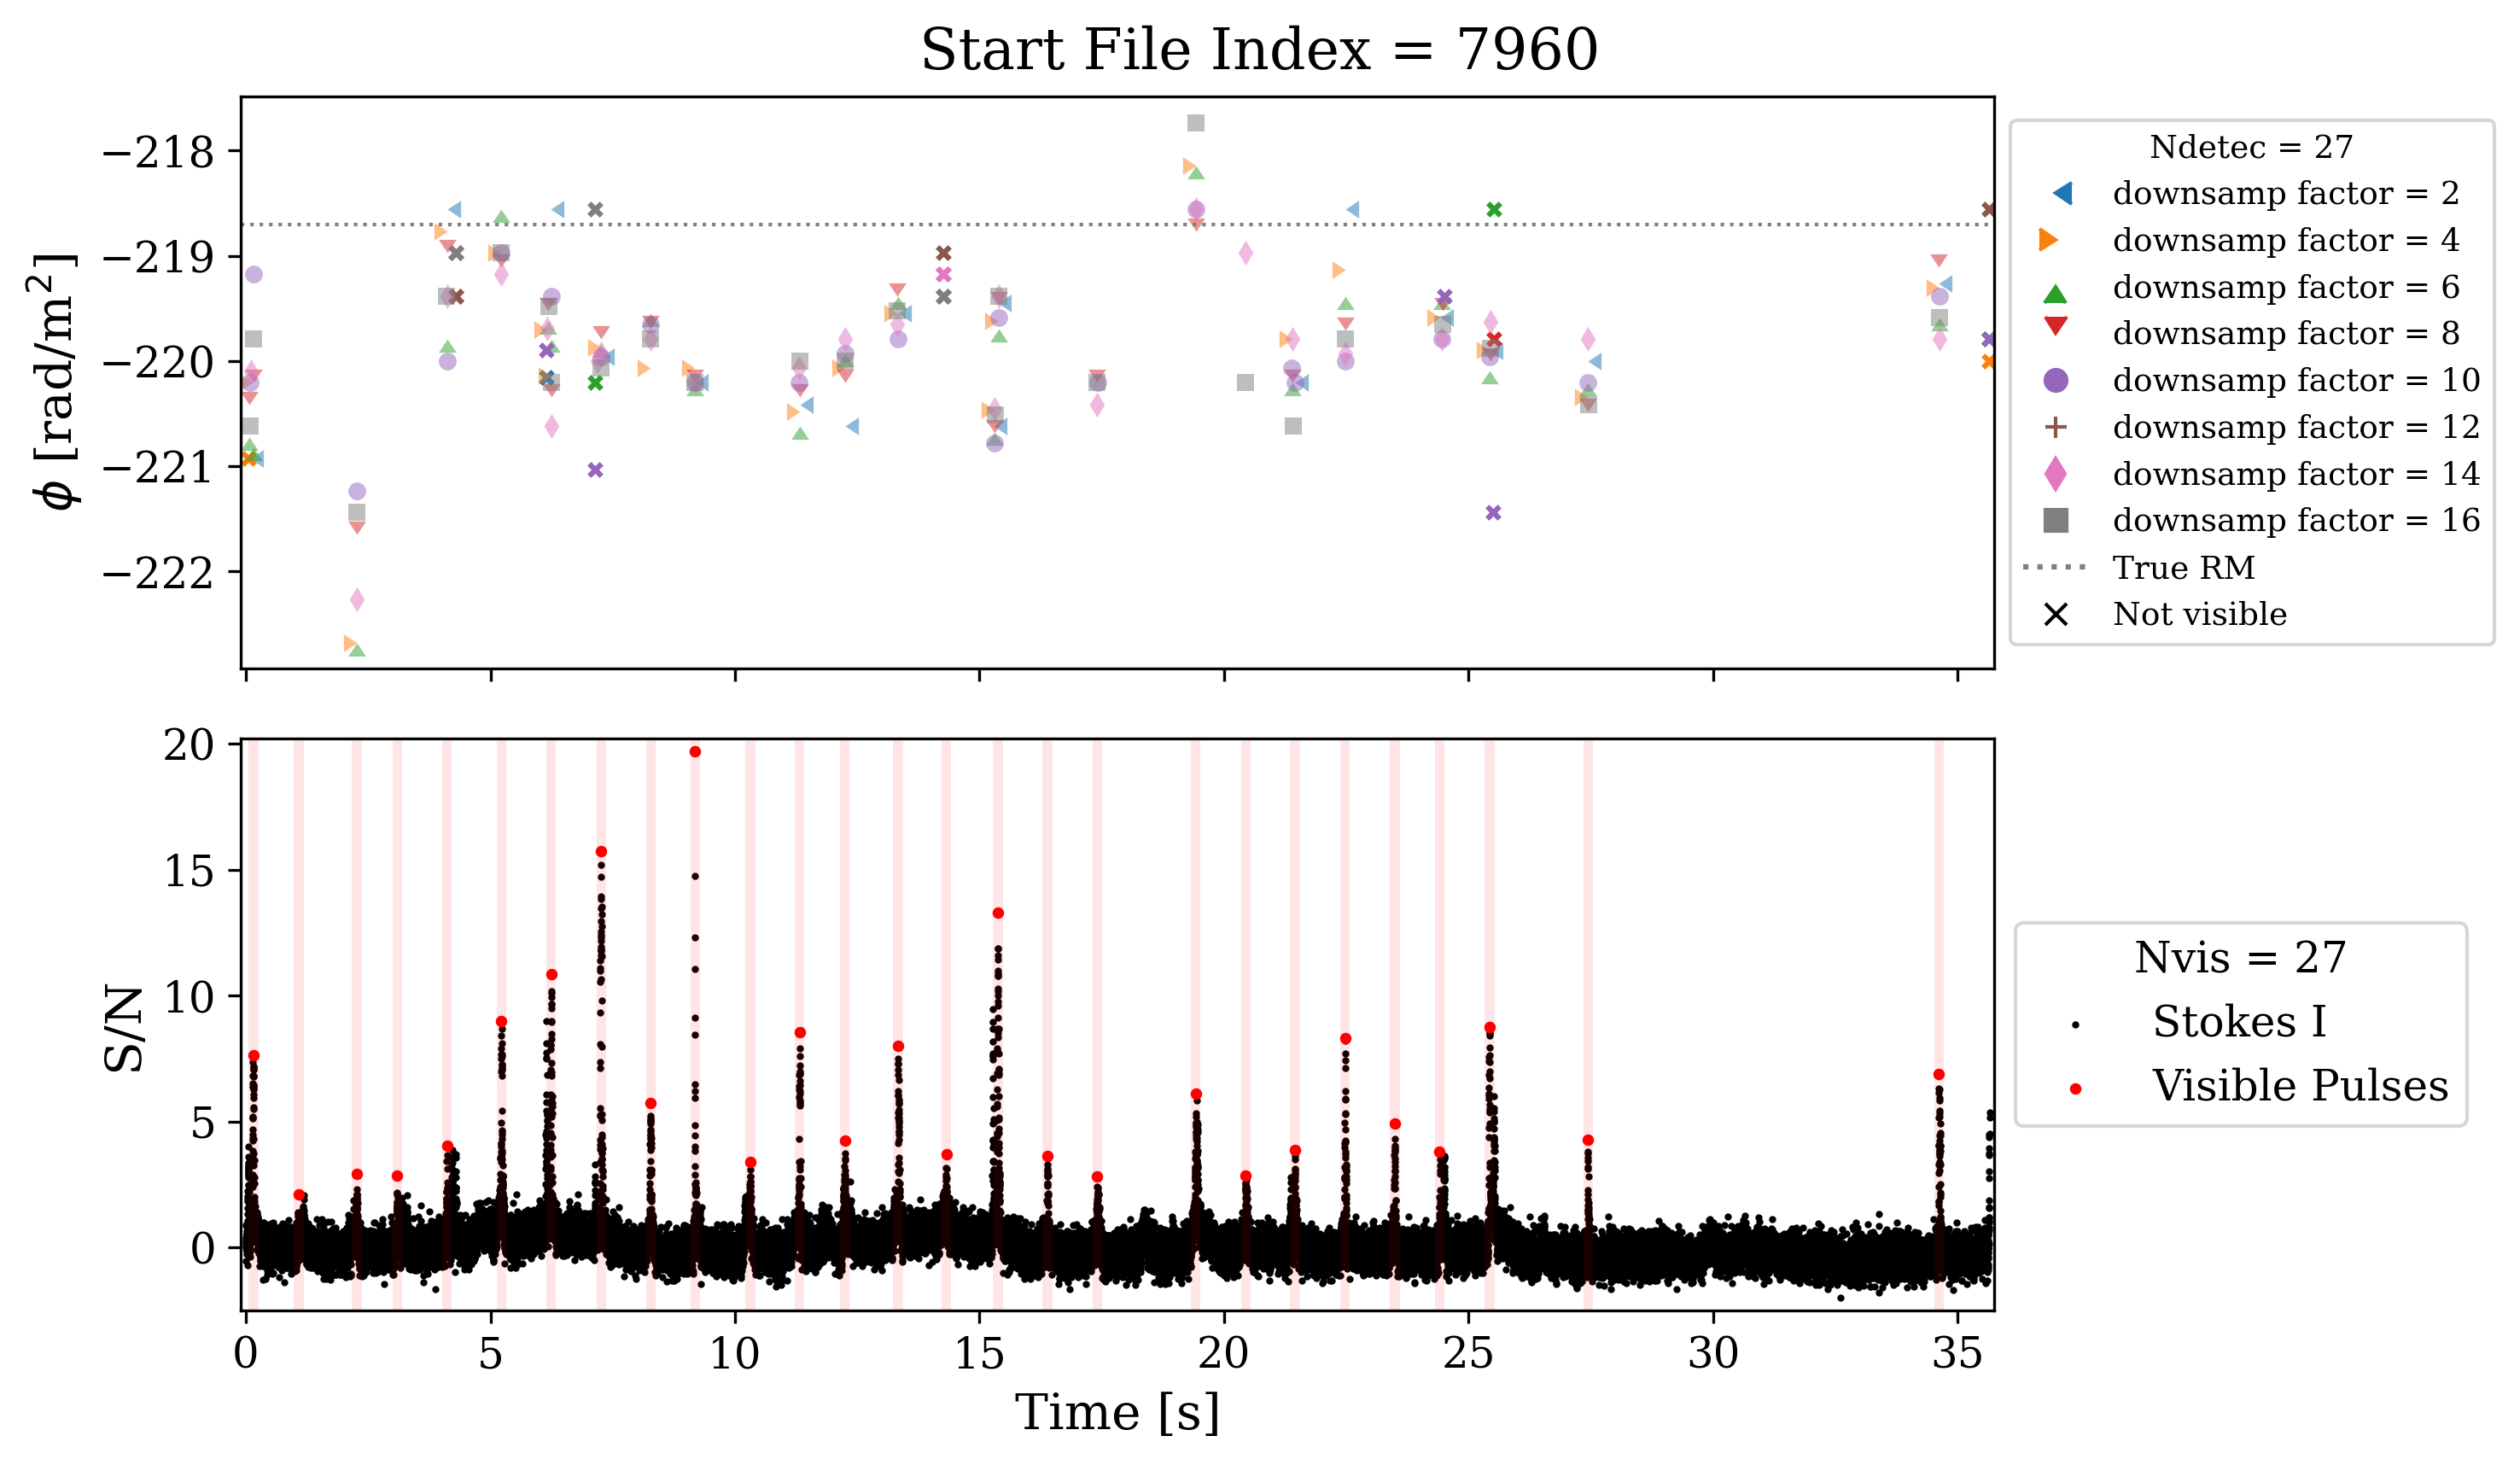

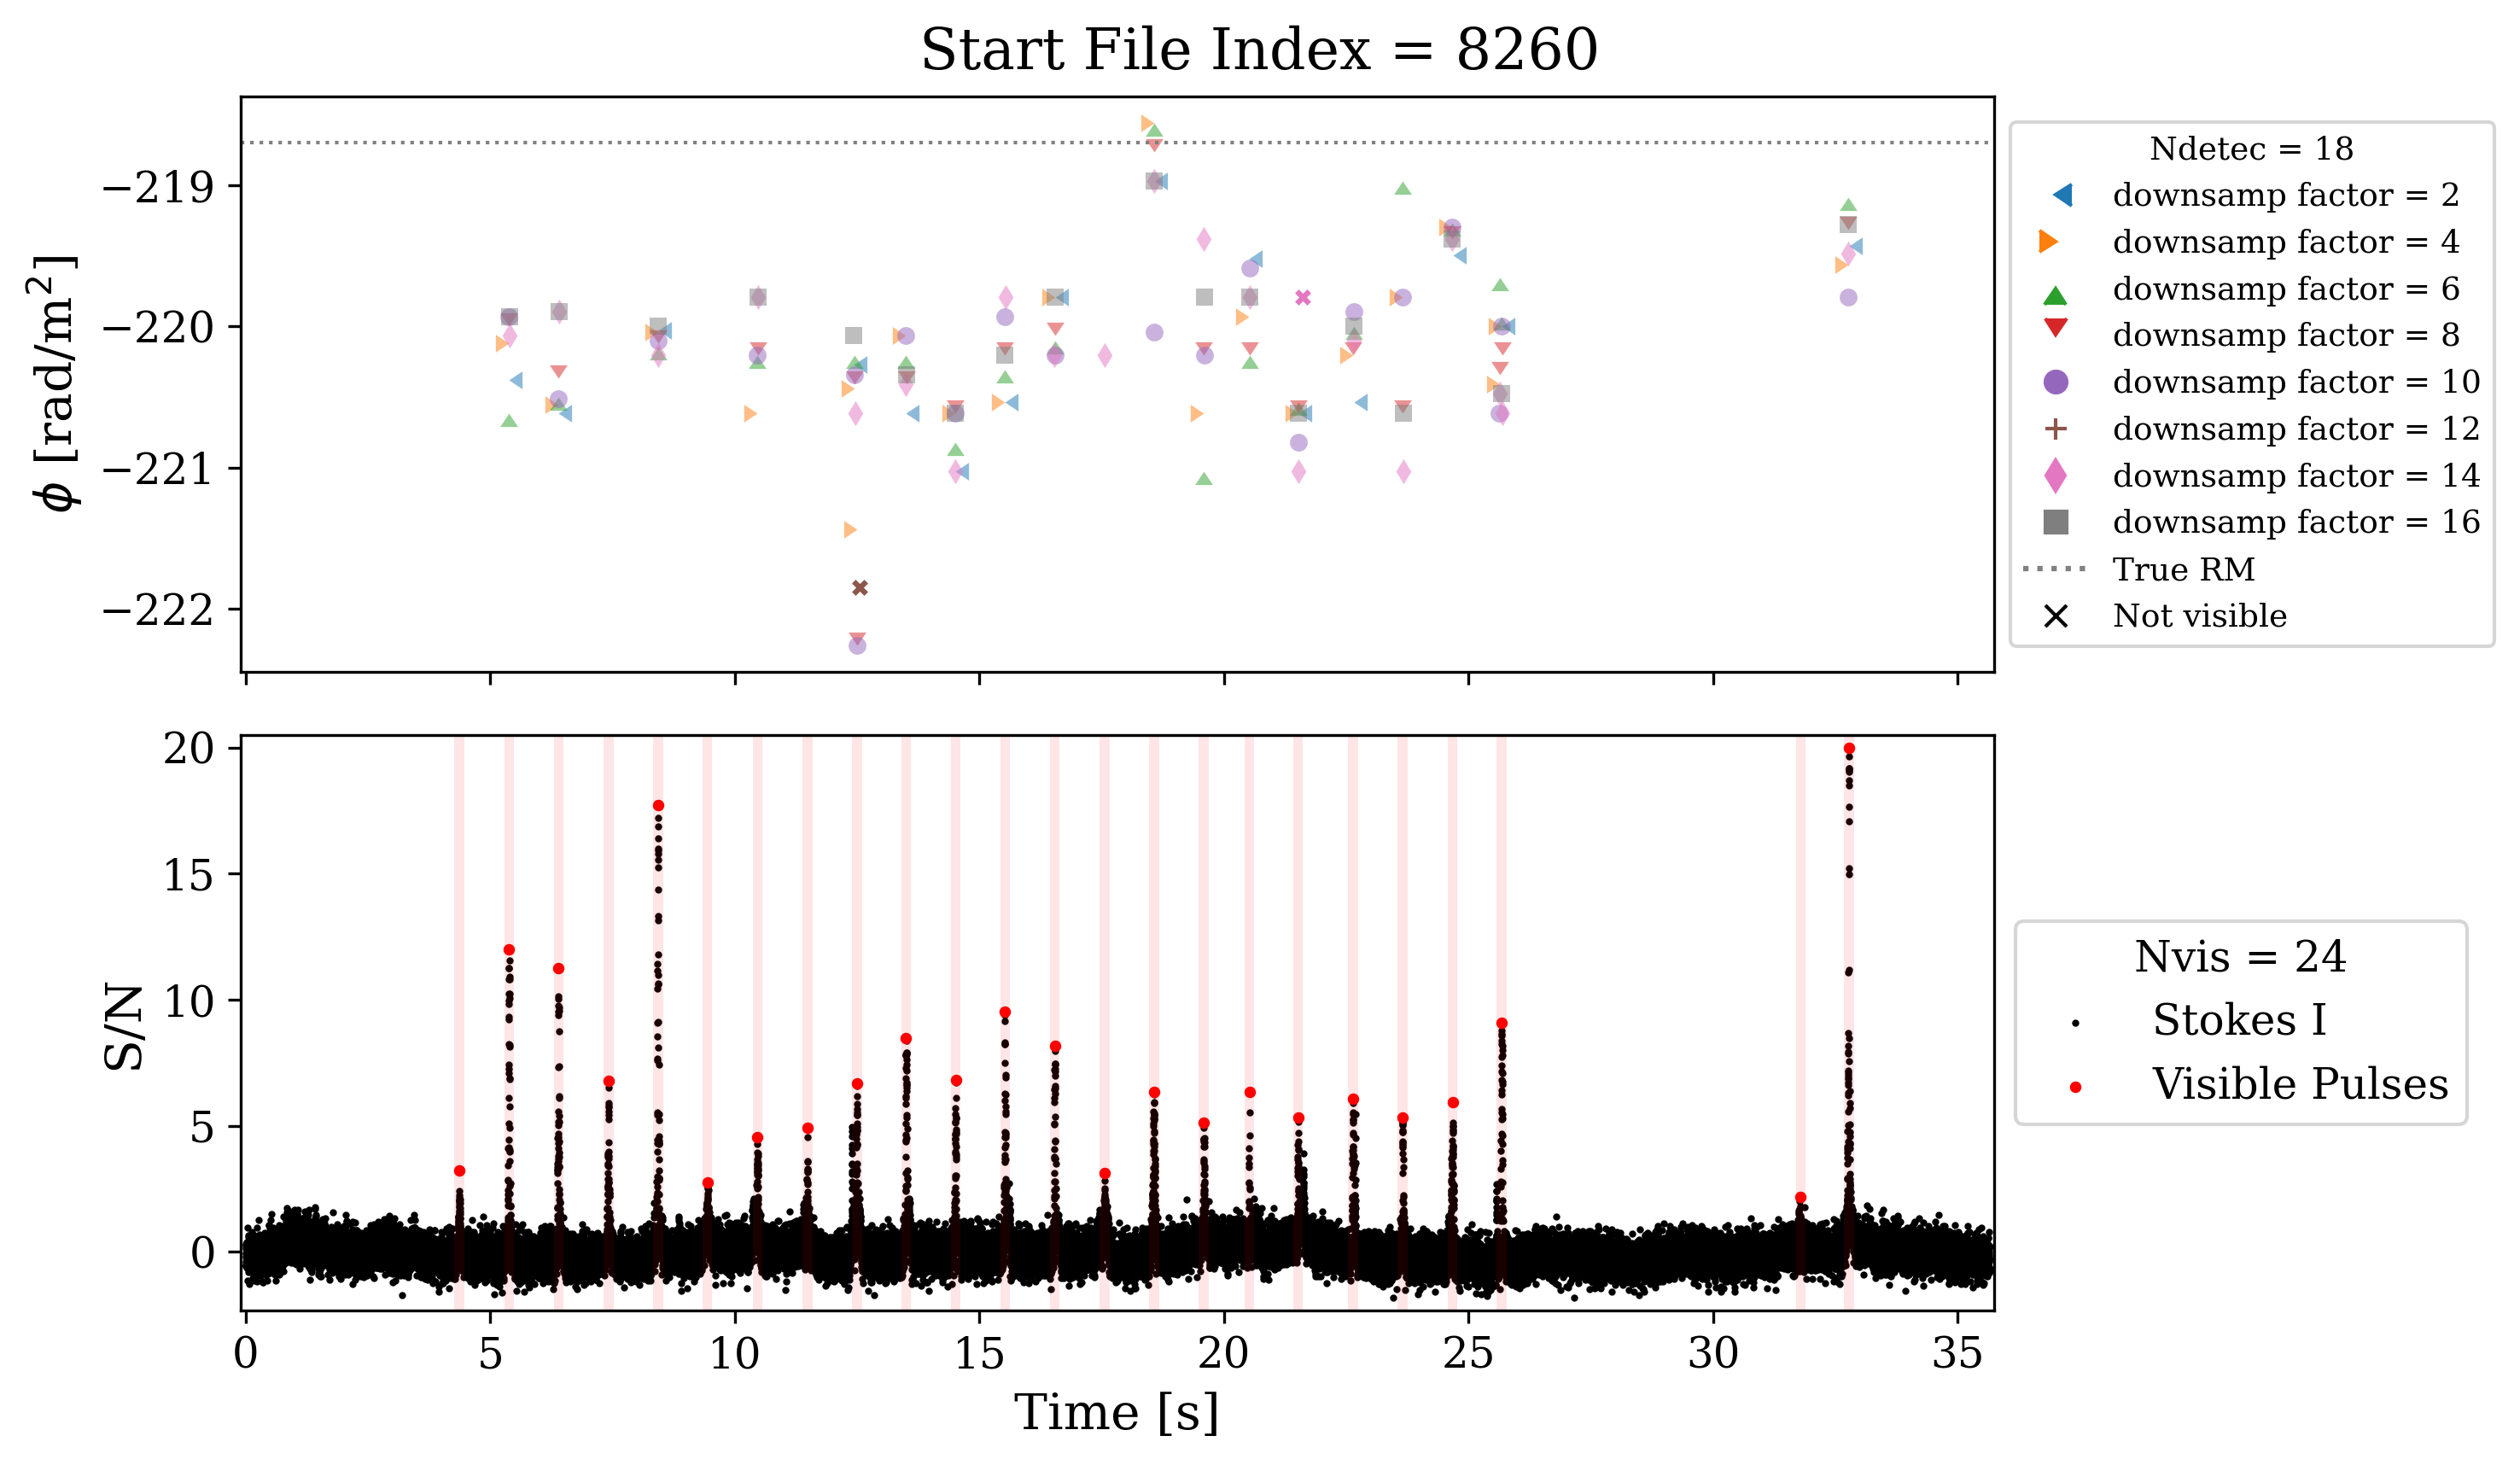

In [158]:
# plot by param
# ----------------
for p in param_list[-5:-2]:

    # ----- Define figure -----
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(10, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [1, 1]}
    )
    fig.suptitle(f"{PARAM_LABEL} = {p:.0f}", y=0.95)

    # ----- Get Data -----
    stokes_I = data[p]['full_stokes'][0]  # shape (Nstokes, Ntimes, Nfreqs)
    time_arr = data[p]['time']  # shape (Ntimes,)
    phi_arr = data[p]['phi_array']

    # ----- Compute & Plot Stokes Timeseries -----
    timeseries = np.nanmean(stokes_I, axis=1)  # Average over frequency
    median = np.nanmedian(timeseries)
    std = np.nanstd(timeseries)
    snr_timeseries = (timeseries - median) / std

    ax_bot.scatter(time_arr, snr_timeseries, 
                   color='black', s=1, zorder=1,
                   label='Stokes I')

    # ----- Get & Plot Visible Pulses -----
    visible_scatter_idx = visible_dict[p]['visible_bursts']
    Nvis = visible_dict[p]['num_pulses_visible']

    ax_bot.scatter(time_arr[visible_scatter_idx], 
                   snr_timeseries[visible_scatter_idx],
                   color='red', s=5, zorder=3,
                   label='Visible Pulses'
                  )
                   
    for v in visible_scatter_idx:
        ax_bot.axvspan(xmin=time_arr[v]-0.1, 
                       xmax=time_arr[v]+0.1,
                       color='red', alpha=0.1, zorder=2,
                       linewidth=0
                      )
    
    # ----- Colors for Downsampling Factors -----
    num_colors = len(downsamp_list)
    cmap = plt.get_cmap('tab10' if num_colors <= 10 else 'tab20')
    colors = [cmap(i) for i in range(num_colors)]
    markers = [4,5,6,7,'o','+','d', 's']
    
    for i,downsamp in enumerate(downsamp_list):
        # ----- Get All Bursts Info -----
        allbursts = results_params_all_downsamp[i][p]['detected_bursts']
        notvis_intervals = set(results_params_all_downsamp[i][p]['notvisible_intervals'])
        Ndetec = len(allbursts)
        Nnotvis = len(notvis_intervals)

        # --- Plot Bursts individually -----
        for burst in allbursts:
            burst_times = []
            # burst_phi_idx = []
            phi_mean = []

            # get info for each detection of a burst
            for b in burst:
                t = b["time"]
                peaks = b["peaks"]
        
                # burst_times.extend([t] * len(peaks))
                # burst_phi_idx.extend(peaks)
                burst_times.append(t)
                phi_mean.append(np.mean(phi_arr[peaks])) 

            # check if classified as visible or not in Stokes I
            t_interval = burst_times[0], burst_times[-1]
            notvis_flag = t_interval in notvis_intervals
            m = "x" if notvis_flag else markers[i]
            lw = 1.5 if notvis_flag else 0
            alpha = 1 if notvis_flag else 0.5
            s = 12 if notvis_flag else 25
            
            # Add all burst data to top panel
            ax_top.scatter(np.mean(burst_times), np.mean(phi_mean), 
                           s=s, marker=m, color=colors[i], 
                           lw=lw, alpha=alpha, 
                           label=f"downsamp factor = {downsamp_list[i]:.0f}")
            # ax_top.plot(burst_times, phi_mean, lw=1, color=colors[i])
                

    # ----- Plot True RM -----
    for rm in rm_true:
        ax_top.axhline(y=rm, ls=':', color='grey', lw=1)
        
    # ----- Legends -----
    ax_bot.legend(title=f"Nvis = {Nvis}", loc="center left", bbox_to_anchor=(1, 0.5))
    ax_top.legend(
        title=f"Ndetec = {Ndetec}",
        loc="center left", bbox_to_anchor=(1, 0.5),
        title_fontsize = 9, fontsize=9,
        handles=[
        *[
            Line2D([0],[0], marker=markers[i], color='none',
                   markerfacecolor=colors[i], markeredgecolor=colors[i],
                   linestyle='None', label=f"downsamp factor = {downsamp_list[i]:.0f}")
            for i in range(len(downsamp_list))
        ],
        Line2D([0],[0], color='grey', ls=':', label='True RM'),
        Line2D([0],[0], marker='x', color='black',
               linestyle='None', label='Not visible')
    ])
    

    # ----- Axes -----
    ax_top.set_ylabel(r'$\phi$ [rad/m$^2$]')
    ax_bot.set_xlabel("Time [s]")
    ax_bot.set_ylabel("S/N")
    ax_bot.set_ylim(np.min(snr_timeseries)-0.5, np.max(snr_timeseries)+0.5)
    for ax in [ax_top, ax_bot]:
        ax.set_xlim(np.min(time_arr)-0.1, np.max(time_arr)+0.1)
    
    fig.tight_layout()
    plt.show()

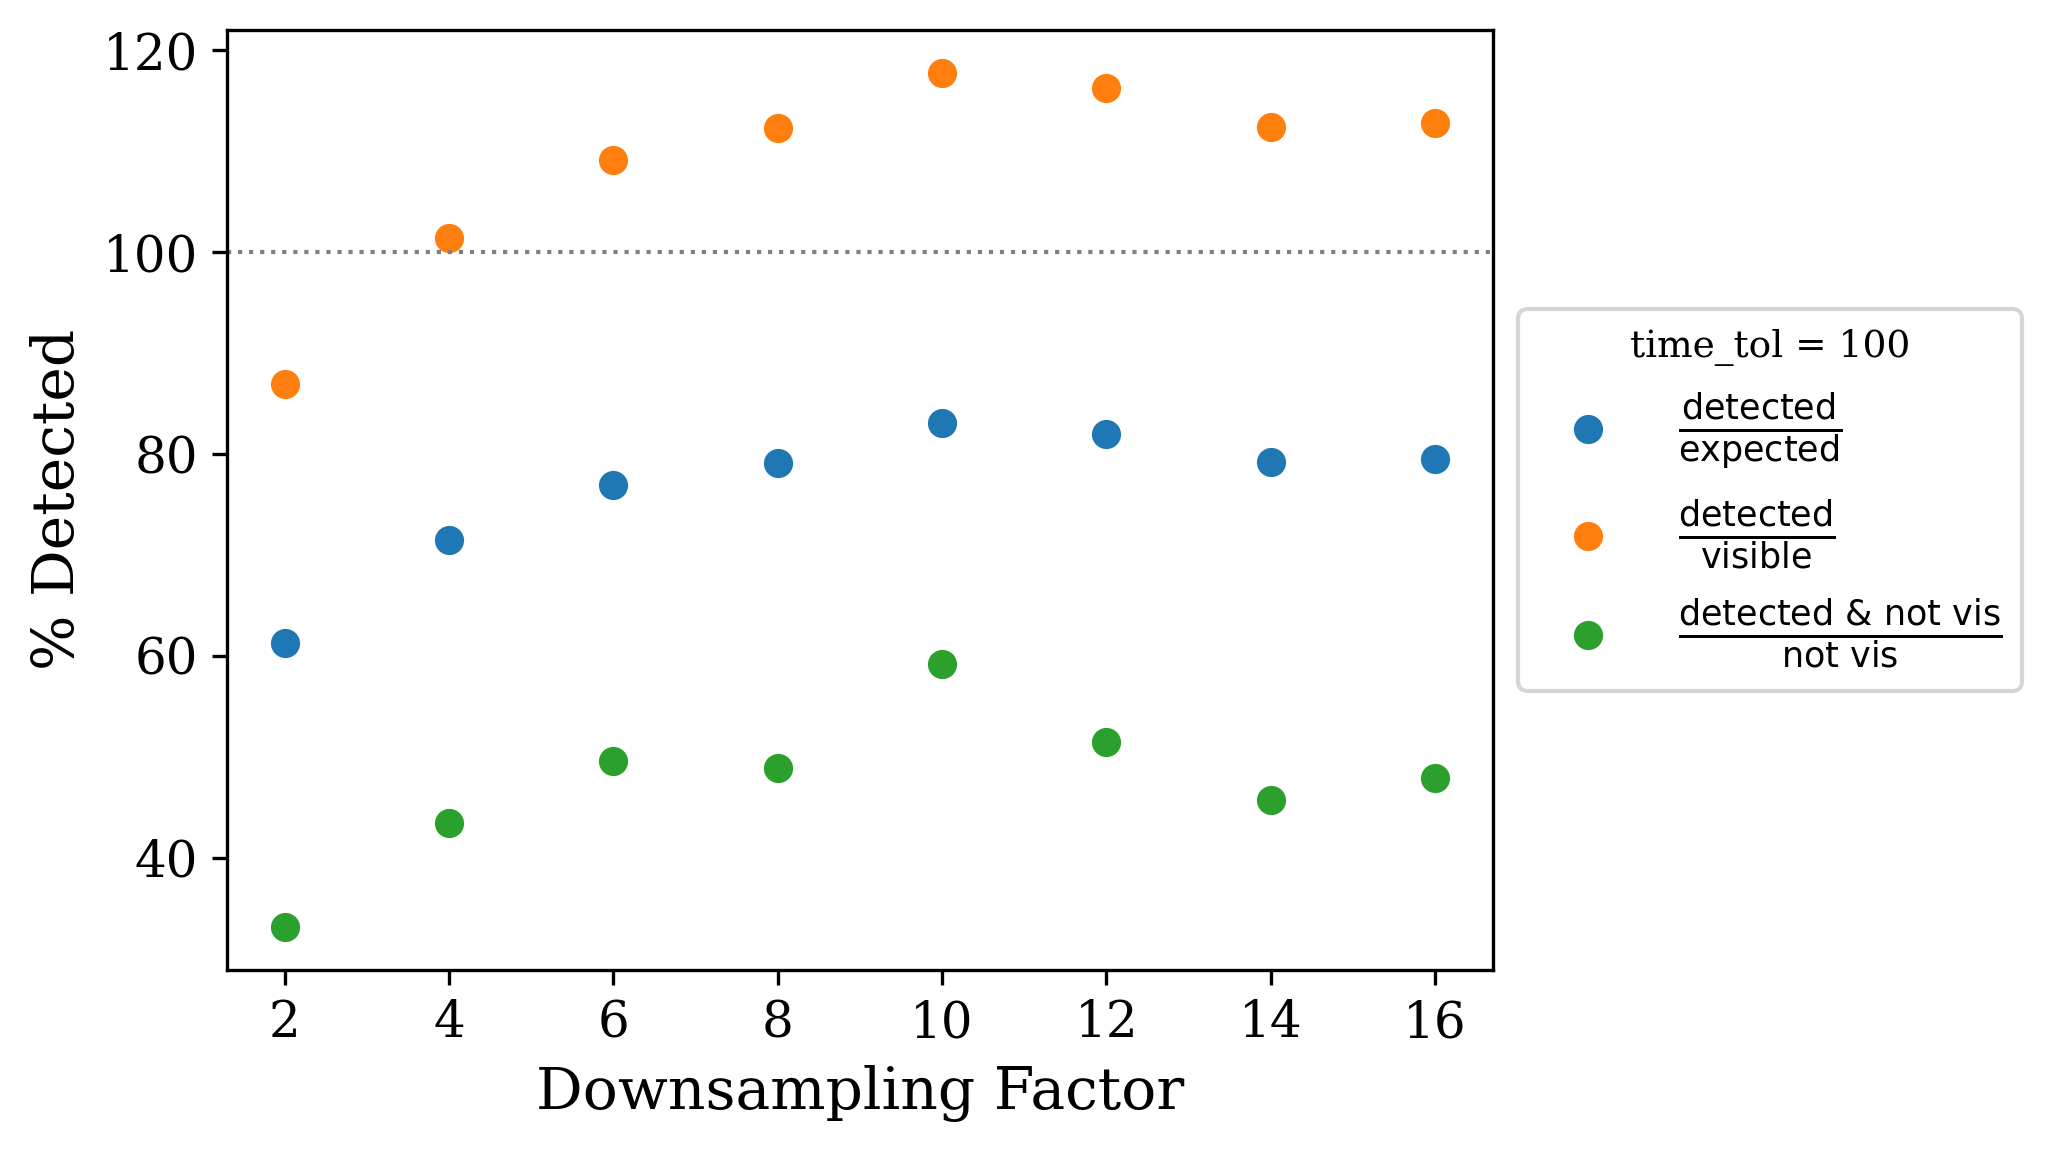

In [157]:
# Plot total % detections (across all files) vs downsampling factor
# --------------------------------------------------------------------------
num_bursts_expected_tot = np.array([ 
    results_summary_all_downsamp[i]["num_bursts_expected_tot"] 
    for i in range(len(downsamp_list))
])
num_pulses_visible_tot = np.array([ 
    results_summary_all_downsamp[i]["num_pulses_visible_tot"] 
    for i in range(len(downsamp_list))
])
num_pulses_not_visible_tot = np.array([ 
    results_summary_all_downsamp[i]["num_pulses_not_visible_tot"] 
    for i in range(len(downsamp_list))
])
num_pulses_detected_tot = np.array([ 
    results_summary_all_downsamp[i]["num_pulses_detected_tot"] 
    for i in range(len(downsamp_list))
])
num_pulses_detected_notvisible_tot = np.array([ 
    results_summary_all_downsamp[i]["num_pulses_detected_notvisible_tot"] 
    for i in range(len(downsamp_list))
])


plt.figure(figsize=(7,4))
plt.scatter(downsamp_list, num_pulses_detected_tot/num_bursts_expected_tot *100, 
            label=r"$\frac{\text{detected}}{\text{expected}}$")
plt.scatter(downsamp_list, num_pulses_detected_tot/num_pulses_visible_tot *100, 
            label=r"$\frac{\text{detected}}{\text{visible}}$")
plt.scatter(downsamp_list, num_pulses_detected_notvisible_tot/num_pulses_not_visible_tot *100, 
            label=r"$\frac{\text{detected & not vis}}{\text{not vis}}$")
plt.axhline(y=100, ls=':', color='grey', lw=1)

plt.ylabel("% Detected")
plt.xlabel("Downsampling Factor")
plt.legend(title=f"time_tol = {TOL}", title_fontsize=9, loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()